In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from gstools import SRF, Gaussian
from gstools.random import MasterRNG

In [3]:
from scipy import integrate

In [4]:
m = 100
n = 110

In [5]:
x = np.linspace(0, 1, m)

In [6]:
seed = MasterRNG(45)
def one_function(x):
    model = Gaussian(dim = 1, var = 3, len_scale = 0.3)
    srf = SRF(model, seed=seed())
    f = srf.structured([x])
    return f

In [9]:
U = np.zeros((m, n))
for i in range(n):
    U[:, i] = one_function(x)

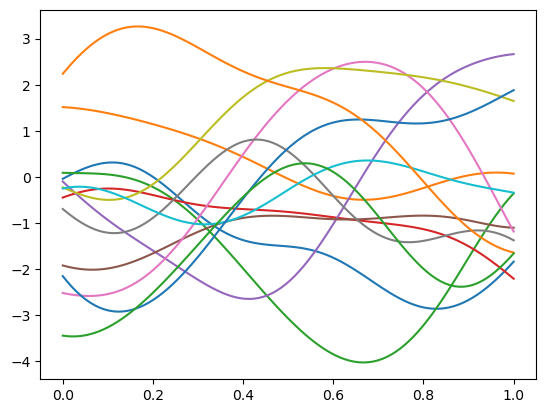

In [10]:
plt.plot(x, U[:, 97:])

In [33]:
x

array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404,
       0.05050505, 0.06060606, 0.07070707, 0.08080808, 0.09090909,
       0.1010101 , 0.11111111, 0.12121212, 0.13131313, 0.14141414,
       0.15151515, 0.16161616, 0.17171717, 0.18181818, 0.19191919,
       0.2020202 , 0.21212121, 0.22222222, 0.23232323, 0.24242424,
       0.25252525, 0.26262626, 0.27272727, 0.28282828, 0.29292929,
       0.3030303 , 0.31313131, 0.32323232, 0.33333333, 0.34343434,
       0.35353535, 0.36363636, 0.37373737, 0.38383838, 0.39393939,
       0.4040404 , 0.41414141, 0.42424242, 0.43434343, 0.44444444,
       0.45454545, 0.46464646, 0.47474747, 0.48484848, 0.49494949,
       0.50505051, 0.51515152, 0.52525253, 0.53535354, 0.54545455,
       0.55555556, 0.56565657, 0.57575758, 0.58585859, 0.5959596 ,
       0.60606061, 0.61616162, 0.62626263, 0.63636364, 0.64646465,
       0.65656566, 0.66666667, 0.67676768, 0.68686869, 0.6969697 ,
       0.70707071, 0.71717172, 0.72727273, 0.73737374, 0.74747

In [43]:
def integrate_one_function(f):
    result = np.zeros_like(f)
    result[0] = 0
    for i in range(1, len(f)):
        result[i] = integrate.simps(f[:(i+1)], x[:(i+1)])
    return result

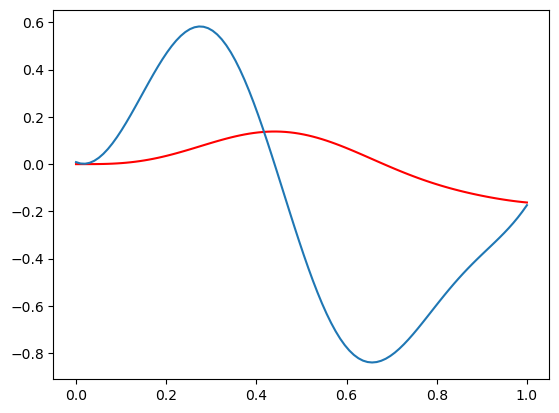

In [45]:
f = U[:, 8]
f_int = integrate_one_function(f)
plt.plot(x, f_int, 'r')
plt.plot(x, f)

In [13]:
S = np.zeros((m,n))
for i in range(n):
    S[:, i] = integrate_one_function(U[:, i])

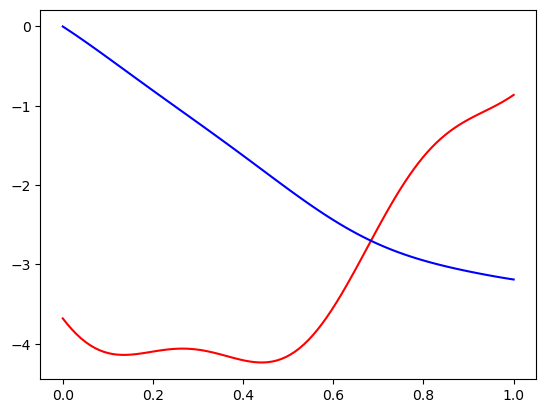

In [93]:
plt.plot(x, U[:,10], 'r')
plt.plot(x, S[:,10], 'b')

In [94]:
# this works for whatever reason
#m = 100
#n = 110

def integrate_data(m=m, n=n, x=x, U=U, S=S):
    us = np.zeros((m*n, m))
    xs = np.zeros((m*n, 1))
    ss = np.zeros((m*n, 1))
    for i in range(n):
        for j in range(m):
            us[i*m+j, :] = U[:, i]
            xs[i*m+j, :] = x[j]
            ss[i*m+j, :] = S[j, i]
    return us, xs, ss

In [ ]:
#m = 100
#n = 110

def integrate_data(m=m, n=n, x=x, U=U, S=S):
    us = np.zeros((m*n, m))
    xs = np.zeros((m*n, 1))
    ss = np.zeros((m*n, 1))
    for i in range(n):
        for j in range(m):
            us[i*m+j, :] = U[:, i]
            xs[i*m+j, :] = x[j]
            ss[i*m+j, :] = S[j, i]
    return us, xs, ss

In [95]:
us, xs, ss = integrate_data()
print(us.shape, xs.shape, ss.shape)

(11000, 100) (11000, 1) (11000, 1)


In [96]:
def batch_dataset(batch_size, m=m, n=n, x=x, U=U, S=S, ratio=0.9):
    us, xs, ss = integrate_data(m, n, x, U, S)
    train_size = int(len(us)*ratio)
    us_train = us[:train_size]
    xs_train = xs[:train_size]
    ss_train = ss[:train_size]

    us_test = us[train_size:]
    xs_test = xs[train_size:]
    ss_test = ss[train_size:]

    us_train = torch.tensor(us_train, dtype=torch.float32)
    xs_train = torch.tensor(xs_train, dtype=torch.float32)
    ss_train = torch.tensor(ss_train, dtype=torch.float32)
    train_dataset = torch.utils.data.TensorDataset(us_train, xs_train, ss_train)
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    us_test = torch.tensor(us_test, dtype=torch.float32)
    xs_test = torch.tensor(xs_test, dtype=torch.float32)
    ss_test = torch.tensor(ss_test, dtype=torch.float32)
    test_dataset = torch.utils.data.TensorDataset(us_test, xs_test, ss_test)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    return train_dataloader, test_dataloader

In [97]:
train_data, test_data = batch_dataset(batch_size=32, ratio=0.9)

In [98]:
class DeepONet(nn.Module):
    def __init__(self, neurons=40, in1=1, in2=1, output_neurons=20):
        super(DeepONet, self).__init__()
        self.in1 = in1
        self.in2 = in2
        self.output_neurons = output_neurons
        self.neurons = neurons

        self.branch = self.branch_network()
        self.trunk = self.trunk_network()

    def branch_network(self):
        branch = nn.Sequential(nn.Linear(self.in1, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.output_neurons))
        return branch


    def trunk_network(self):
        trunk = nn.Sequential(nn.Linear(self.in2, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.output_neurons))
        return trunk


    def forward(self, x1, x2):
        x1 = self.branch(x1)
        x2 = self.trunk(x2)
        x = torch.einsum("bi, bi-> b", x1, x2)
        x = torch.unsqueeze(x, 1)
        return x


In [99]:
model = DeepONet(neurons = 40, in1 = m, in2=1)

In [100]:
def loss(y_pred, y):
    return torch.mean((y_pred - y)**2)

In [101]:
optimizer = torch.optim.Adam(model.parameters(), lr=.001)

In [102]:
train_losses = []
epochs = 200
for i in range(epochs):
    l_total = 0
    for u_batch, x_batch, s_batch in train_data:
        model.train()
        optimizer.zero_grad()
        y_pred = model(u_batch, x_batch)

        l = loss(y_pred, s_batch)
        l_total += l.item()
        l.backward()
        optimizer.step()

    l_total = l_total/len(train_data)
    train_losses.append(l_total)

    if i%20 == 0:
        print("Epoch:  ", i, "/", epochs, "loss: ", l_total)

    

Epoch:   0 / 200 loss:  0.04778363561678317
Epoch:   20 / 200 loss:  0.0017545978666373319
Epoch:   40 / 200 loss:  0.000223092752827553
Epoch:   60 / 200 loss:  0.0006588298336165251
Epoch:   80 / 200 loss:  0.0001545185375430118
Epoch:   100 / 200 loss:  0.00012883495202855086
Epoch:   120 / 200 loss:  0.00018242084147312843
Epoch:   140 / 200 loss:  0.00011935003720047403
Epoch:   160 / 200 loss:  0.0003412508794187283
Epoch:   180 / 200 loss:  6.131802943385875e-05


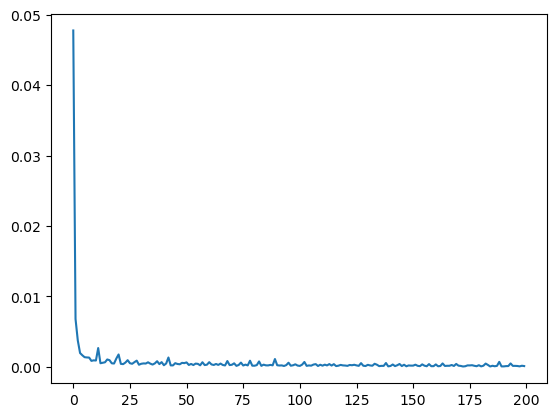

In [103]:
plt.plot(train_losses)

In [104]:
my_func = lambda x: np.cos(5*x)

In [105]:
inter_my_func = lambda  x:(1/5)*np.sin(5*x)

In [106]:
u_t = my_func(x)
s_t = inter_my_func(x)

In [107]:
model.eval()

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=100, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=20, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=1, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): ReLU()
    (6): Linear(in_features=40, out_features=20, bias=True)
  )
)

In [108]:
u_t_tens = torch.tensor(u_t, dtype = torch.float32)
#print(u_t_tens)
u_t_tens = torch.tensor(u_t, dtype = torch.float32).unsqueeze(0)
#print(u_t_tens)
x_tens = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
#print(x_tens)

In [109]:
print(u_t_tens.shape)

torch.Size([1, 100])


In [110]:
p = model(u_t_tens, x_tens)

In [111]:
p=p.detach().numpy()

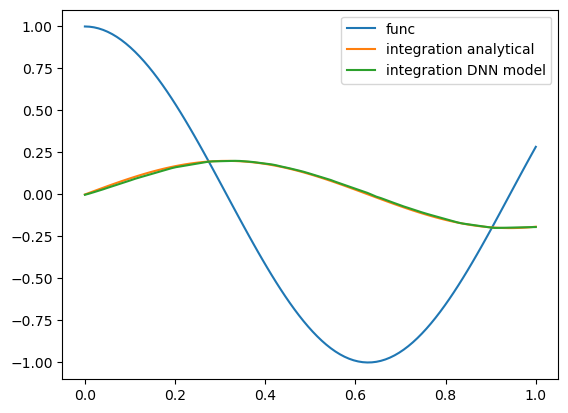

In [112]:
plt.plot(x, u_t, label = "func")
plt.plot(x, s_t, label = "integration analytical")
plt.plot(x, p, label = "integration DNN model")
plt.legend()